---

# Plota Mapa de Quantidade de Dias Secos, Temperatura Máxima no Mês de Agosto de 2024 Acima do Percentil de 90% com Dados do CPC e Focos de Calor.

---

- `REALIZADO POR`:
> Prof. Enrique V. Mattos / UNIFEI - 29/05/2026

- `ATUALIZADO POR`:
> Prof. Enrique V. Mattos / UNIFEI - 29/05/2026
---

# Prepando ambiente


In [1]:
#=========================================================================================================================#
#                                          INSTALAÇÃO E IMPORTAÇÃO DAS BIBLIOTECAS
#=========================================================================================================================#
# instala bibliotecas
!pip install -q xarray dask netCDF4 bottleneck xclim ultraplot cartopy salem rasterio pyproj geopandas

# importa bibliotecas
import xarray as xr
import xclim as xc
import ultraplot as uplt
import salem
import os
import cartopy.io.shapereader as shpreader
import cartopy.crs as ccrs
import numpy as np
from dask.diagnostics import ProgressBar
from matplotlib.ticker import FormatStrFormatter
from cartopy.mpl.patch import geos_to_path
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import warnings
warnings.filterwarnings("ignore")

#=========================================================================================================================#
#                                  MONTA O GOOGLE DRIVE E CRIA O DIRETÓRIO DE SAÍDA
#=========================================================================================================================#
# monta o drive
from google.colab import drive
drive.mount('/content/drive')

# diretório raiz
dir = '/content/drive/MyDrive/2-PESQUISA/artigo_queimadas_Paola_2026/0_round1_revisoes/dias_secos_e_diasacimaP90_e_focoscalor'

#=========================================================================================================================#
#                                  DEFINE OS LIMITES DO BRASIL OU ESTADO DE SÃO PAULO
#=========================================================================================================================#
# limites
lonmin_sp, lonmax_sp, latmin_sp, latmax_sp = -53.3, -43.9, -25.4, -19.7 # estado de SP
#lonmin, lonmax, latmin, latmax = -75.0, -33.0, -35.0, 7.0 # Brasil

# leitura shapefiles
shapefile_sp = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp') # estado de SP
#shapefile_regiao = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/brasil/BRAZIL.shp') # Brasil

# é importante porque o NetCDF usa lon/lat e o Cartopy também vai plotar em PlateCarree
shapefile_sp = shapefile_sp.to_crs("EPSG:4326") # Pois os dois tem que se conversar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.7/384.7 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 78.6 MB/s eta 0:00:00


Mounted at /content/drive


# Plota Figura: Agosto/2024

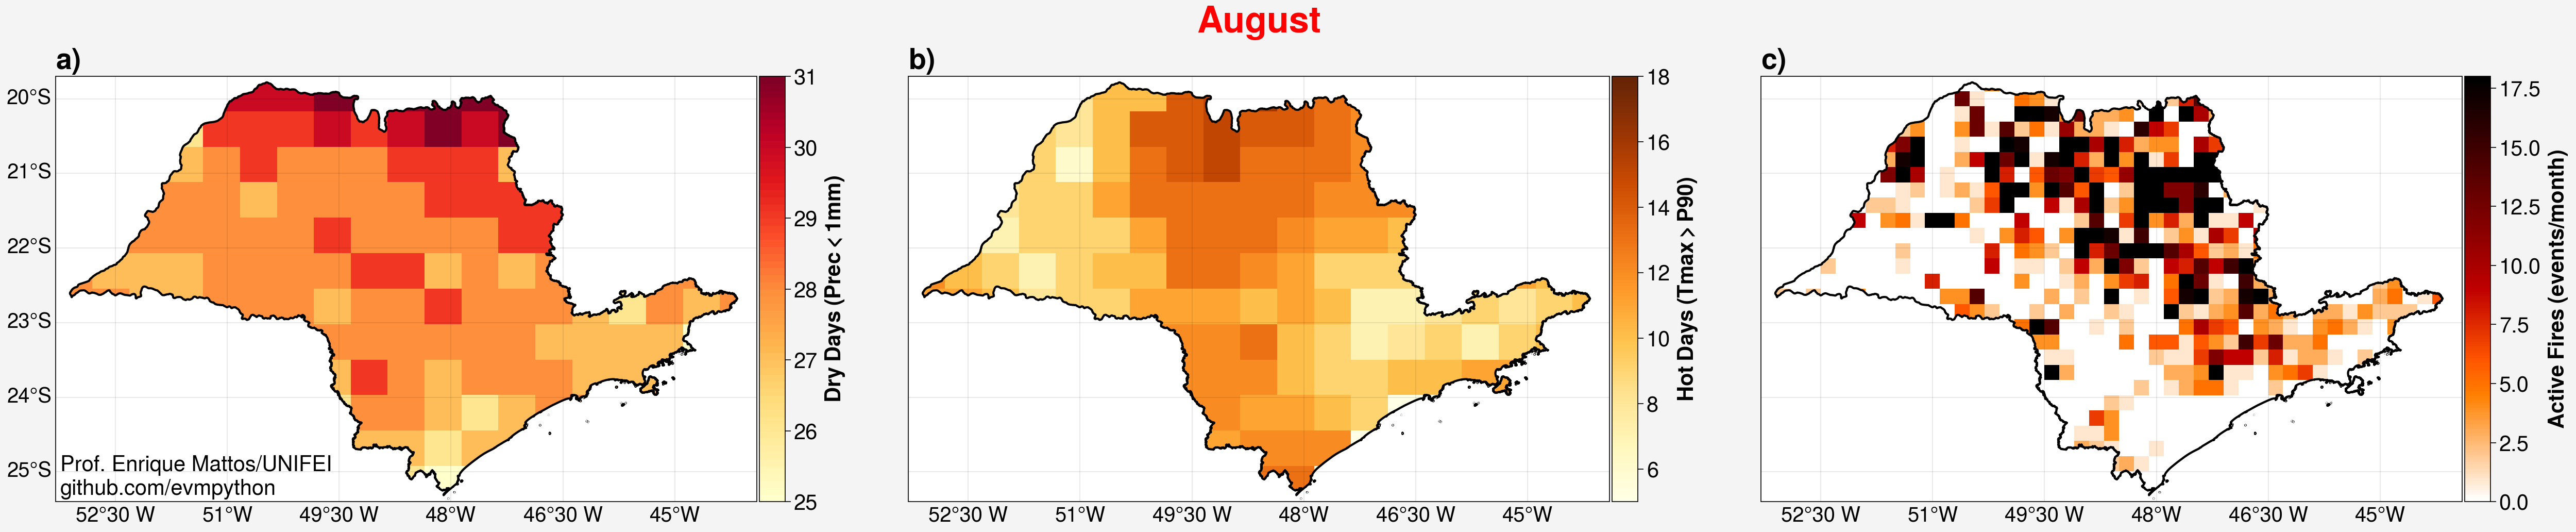

In [8]:
#=========================================================================================================================#
#                                           LEITURA DOS DADOS
#=========================================================================================================================#
dias_secos_ago = xr.open_dataset(f'{dir}/dry_days_cpc_2024-08-01_2024-08-31.nc').sel(lat=slice(latmin_sp, latmax_sp), lon=slice(lonmin_sp, lonmax_sp))

dias_acimaP90_ago = xr.open_dataset(f'{dir}/dias_tmax_acima_p90_08_2024.nc').sel(lat=slice(latmin_sp, latmax_sp), lon=slice(lonmin_sp, lonmax_sp))

focos_calor_ago = xr.open_dataset(f'{dir}/focos_mensal_brasil_AQUA_2024-08.nc').sel(lat=slice(latmax_sp, latmin_sp), lon=slice(lonmin_sp, lonmax_sp))

#=========================================================================================================================#
#                                                  PLOTA MAPA
#=========================================================================================================================#
#------------------------------------------------------------------#
#                      FORMATAÇÃO DA FIGURA
#------------------------------------------------------------------#
# cria a moldura da figura
fig, ax = uplt.subplots(axheight=4.5, axwidth=6.8, ncols=3, tight=True, proj='pcarree')

# parâmetros de formatação dos mapas
ax.format(coast=False, innerborders=False, borders=False,
          labels=True, latlines=1, lonlines=1.5,
          latlim=(latmin_sp, latmax_sp), lonlim=(lonmin_sp, lonmax_sp),
          small='20px',  large='35px',
          suptitle=f'August',
          suptitle_kw = {'color': 'red', 'fontweight': 'bold'},
          grid=True,
          abc=True, abcstyle='a)', abcsize=20)

# coloca numa lista os limites da imagem
extent = [lonmin_sp, lonmax_sp, latmin_sp, latmax_sp]

# adiciona o shapefile do Estado de SP
shapefile_plot_sp = list(shpreader.Reader('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp').geometries())
ax.add_geometries(shapefile_plot_sp, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.5)

#------------------------------------------------------------------#
#                      FIG-1: DIAS SECOS
#------------------------------------------------------------------#
# recorta o dado para SP
dias_secos_ago_roi = dias_secos_ago['precip'][0,:,:]#.salem.roi(shape=shapefile_sp)

# mapa
map1 = ax[0].imshow(np.flipud(dias_secos_ago_roi.values),
                    cmap='YlOrRd',
                    extent=extent,
                    transform=ccrs.PlateCarree(),
                    origin='upper',
                    vmin=25, vmax=31,
                    levels=uplt.arange(25, 31, 0.1))

#------------------------------------------------------------------#
#             Mapa com suavização nas bordas
#------------------------------------------------------------------#
# mesmo que o shapefile tenha mais de uma feição, essa linha junta tudo em uma única geometria
geom_sp = shapefile_sp.geometry.unary_union # isso garante que não vai ter um bug que não reconhece um "polygon"

# pega os limites do shapefile
minx, miny, maxx, maxy = shapefile_sp.total_bounds # aqui é para não bugar com os pixels, usado para recortar usando o shape de são paulo e não usando o pixel

# converte a geometria do shapefile de SP em um caminho do Matplotlib
paths = geos_to_path([geom_sp])

# junta todos os caminhos em um único, pois assim fica tudo em unico recorte
clip_path = Path.make_compound_path(*paths)

# aqui unifica todos em um unico shape e corte
clip_patch = PathPatch(clip_path, transform=ax[0].transData, facecolor="none")

# aplica o recorte visual no próprio GeoQuadMesh retornado pelo xarray.plot()
# essa linha faz o dado aparecer somente dentro do limite de SP
map1.set_clip_path(clip_patch)
#------------------------------------------------------------------#

# barra de cores
cbar1 = ax[0].colorbar(map1,
                       loc='r',
                       ticks=uplt.arange(25, 31, 1),
                       label='Dry Days (Prec < 1 mm)',
                       ticklabelsize=15,
                       labelsize=15,
                       space=0.2,
                       width=0.25)
cbar1.ax.set_ylabel("$\\mathbf{Dry\\;Days\\;(Prec < 1 mm)}$", rotation=90, labelpad=20)
cbar1.ax.minorticks_off()

# informação na figura
ax[0].annotate('Prof. Enrique Mattos/UNIFEI\ngithub.com/evmpython', xy=(lonmin_sp+0.06,latmin_sp+0.09), fontsize=15, color='black')

#------------------------------------------------------------------#
#                      FIG-2: TMAX > P90
#------------------------------------------------------------------#
# recorta o dado para SP
dias_acimaP90_ago_roi = dias_acimaP90_ago['dias_acima_p90_agosto_2024'][:,:] #.salem.roi(shape=shapefile_sp)

# mapa
map2 = ax[1].imshow(np.flipud(dias_acimaP90_ago_roi.values),
                    cmap='YlOrBr',
                    extent=extent,
                    transform=ccrs.PlateCarree(),
                    origin='upper',
                    vmin=5, vmax=18,
                    levels=uplt.arange(5, 18, 0.1))

#------------------------------------------------------------------#
#             Mapa com suavização nas bordas
#------------------------------------------------------------------#
# mesmo que o shapefile tenha mais de uma feição, essa linha junta tudo em uma única geometria
geom_sp = shapefile_sp.geometry.unary_union # isso garante que não vai ter um bug que não reconhece um "polygon"

# pega os limites do shapefile
minx, miny, maxx, maxy = shapefile_sp.total_bounds # aqui é para não bugar com os pixels, usado para recortar usando o shape de são paulo e não usando o pixel

# converte a geometria do shapefile de SP em um caminho do Matplotlib
paths = geos_to_path([geom_sp])

# junta todos os caminhos em um único, pois assim fica tudo em unico recorte
clip_path = Path.make_compound_path(*paths)

# aqui unifica todos em um unico shape e corte
clip_patch = PathPatch(clip_path, transform=ax[1].transData, facecolor="none")

# aplica o recorte visual no próprio GeoQuadMesh retornado pelo xarray.plot()
# essa linha faz o dado aparecer somente dentro do limite de SP
map2.set_clip_path(clip_patch)
#------------------------------------------------------------------#

# barra de cores
cbar2 = ax[1].colorbar(map2,
                       loc='r',
                       ticks=uplt.arange(6, 18, 2),
                       label='',
                       ticklabelsize=15,
                       labelsize=15,
                       space=0.2,
                       width=0.25)
cbar2.ax.set_ylabel("$\\mathbf{Hot\\;Days\\;(Tmax > P90)}$", rotation=90, labelpad=20)
cbar2.ax.minorticks_off()

#------------------------------------------------------------------#
#                      FIG-3: FOCOS DE CALOR
#------------------------------------------------------------------#
# mapa
map3 = ax[2].imshow(np.flipud(focos_calor_ago['focos'].values),
                    cmap='gist_heat_r',
                    extent=[lonmin_sp, lonmax_sp, latmax_sp, latmin_sp],
                    transform=ccrs.PlateCarree(),
                    origin='upper',
                    vmin=5, vmax=18,
                    levels=uplt.arange(0, 18, 0.1))

#------------------------------------------------------------------#
#             Mapa com suavização nas bordas
#------------------------------------------------------------------#
# mesmo que o shapefile tenha mais de uma feição, essa linha junta tudo em uma única geometria
geom_sp = shapefile_sp.geometry.unary_union # isso garante que não vai ter um bug que não reconhece um "polygon"

# pega os limites do shapefile
minx, miny, maxx, maxy = shapefile_sp.total_bounds # aqui é para não bugar com os pixels, usado para recortar usando o shape de são paulo e não usando o pixel

# converte a geometria do shapefile de SP em um caminho do Matplotlib
paths = geos_to_path([geom_sp])

# junta todos os caminhos em um único, pois assim fica tudo em unico recorte
clip_path = Path.make_compound_path(*paths)

# aqui unifica todos em um unico shape e corte
clip_patch = PathPatch(clip_path, transform=ax[2].transData, facecolor="none")

# aplica o recorte visual no próprio GeoQuadMesh retornado pelo xarray.plot()
# essa linha faz o dado aparecer somente dentro do limite de SP
map3.set_clip_path(clip_patch)
#------------------------------------------------------------------#

# barra de cores
cbar3 = ax[2].colorbar(map3,
                       loc='r',
                       ticks=uplt.arange(0, 18, 2.5),
                       label='',
                       ticklabelsize=15,
                       labelsize=15,
                       space=0.2,
                       width=0.25)
cbar3.ax.set_ylabel("$\\mathbf{Active\\;Fires\\;(events/month)}$", rotation=90, labelpad=20)
cbar3.formatter = FormatStrFormatter("%.1f")
cbar3.update_ticks()
cbar3.ax.minorticks_off()

#------------------------------------------------------------------#
#                       Salva figura
#------------------------------------------------------------------#
# salva figura
fig.savefig(f'{dir}/Fig_1a_diassecos_tmaxacimaP90_focoscalor_ago2024.jpg', dpi=300, bbox_inches="tight")

# Plota Figura: Setembro/2024

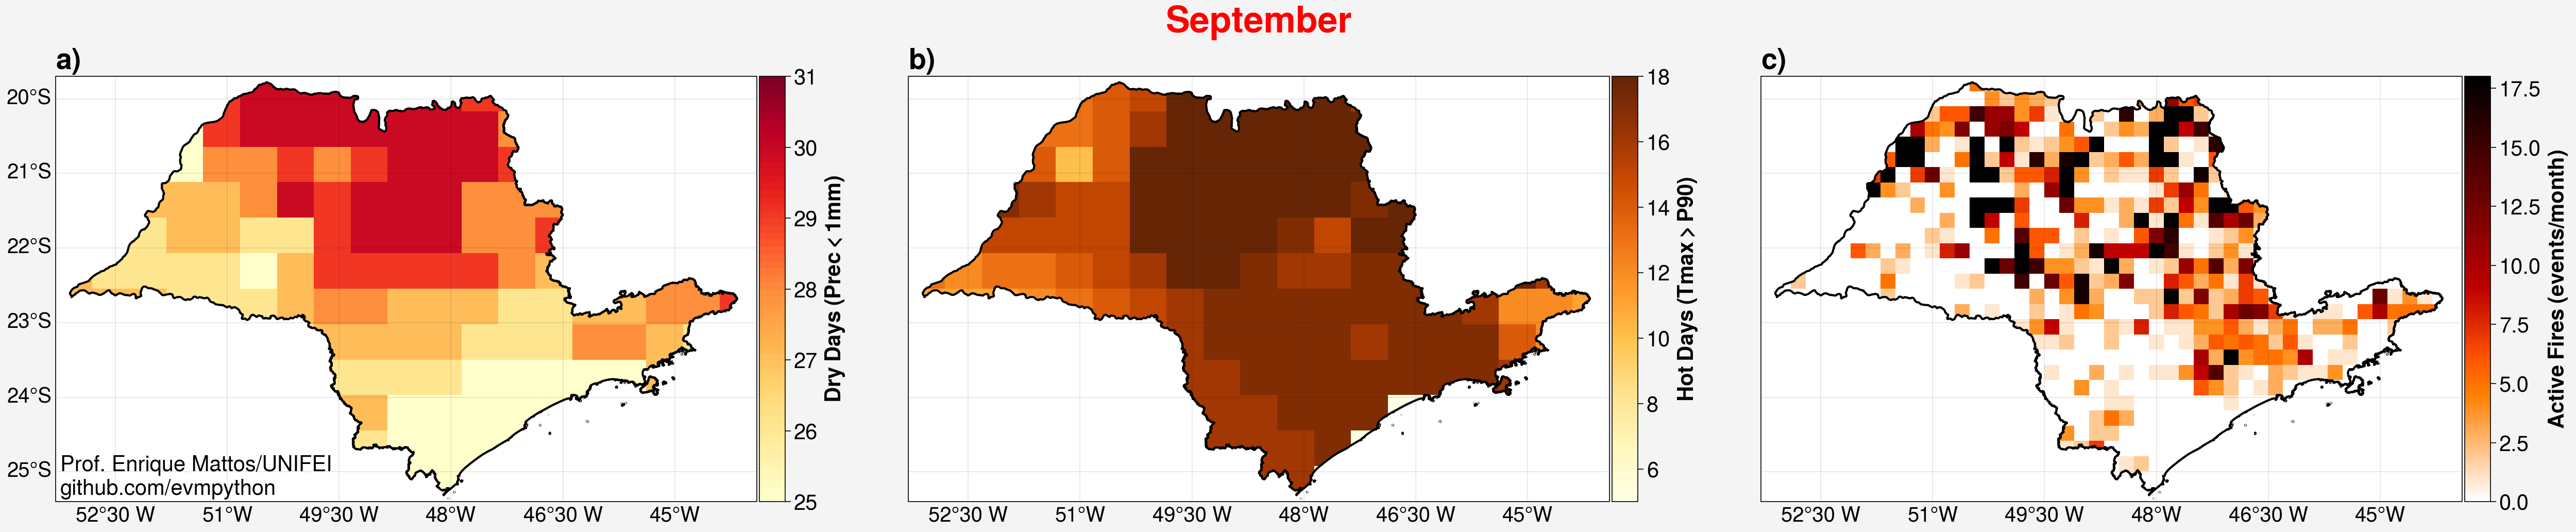

In [9]:
#=========================================================================================================================#
#                                           LEITURA DOS DADOS
#=========================================================================================================================#
dias_secos_set = xr.open_dataset(f'{dir}/dry_days_cpc_2024-09-01_2024-09-30.nc').sel(lat=slice(latmin_sp, latmax_sp), lon=slice(lonmin_sp, lonmax_sp))
dias_acimaP90_set = xr.open_dataset(f'{dir}/dias_tmax_acima_p90_09_2024.nc').sel(lat=slice(latmin_sp, latmax_sp), lon=slice(lonmin_sp, lonmax_sp))
focos_calor_set = xr.open_dataset(f'{dir}/focos_mensal_brasil_AQUA_2024-09.nc').sel(lat=slice(latmax_sp, latmin_sp), lon=slice(lonmin_sp, lonmax_sp))

#=========================================================================================================================#
#                                                  PLOTA MAPA
#=========================================================================================================================#
#------------------------------------------------------------------#
#                      FORMATAÇÃO DA FIGURA
#------------------------------------------------------------------#
# cria a moldura da figura
fig, ax = uplt.subplots(axheight=4.5, axwidth=6.8, ncols=3, tight=True, proj='pcarree')

# parâmetros de formatação dos mapas
ax.format(coast=False, innerborders=False, borders=False,
          labels=True, latlines=1, lonlines=1.5,
          latlim=(latmin_sp, latmax_sp), lonlim=(lonmin_sp, lonmax_sp),
          small='20px',  large='35px',
          suptitle=f'September',
          suptitle_kw = {'color': 'red', 'fontweight': 'bold'},
          grid=True,
          abc=True, abcstyle='a)', abcsize=20)

# coloca numa lista os limites da imagem
extent = [lonmin_sp, lonmax_sp, latmin_sp, latmax_sp]

# adiciona o shapefile do Estado de SP
shapefile_plot_sp = list(shpreader.Reader('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp').geometries())
ax.add_geometries(shapefile_plot_sp, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.5)

#------------------------------------------------------------------#
#                      FIG-1: DIAS SECOS
#------------------------------------------------------------------#
# recorta o dado para SP
dias_secos_set_roi = dias_secos_set['precip'][0,:,:]#.salem.roi(shape=shapefile_sp)

# mapa
map1 = ax[0].imshow(np.flipud(dias_secos_set_roi.values),
                    cmap='YlOrRd',
                    extent=extent,
                    transform=ccrs.PlateCarree(),
                    origin='upper',
                    vmin=25, vmax=31,
                    levels=uplt.arange(25, 31, 0.1))

#------------------------------------------------------------------#
#             Mapa com suavização nas bordas
#------------------------------------------------------------------#
# mesmo que o shapefile tenha mais de uma feição, essa linha junta tudo em uma única geometria
geom_sp = shapefile_sp.geometry.unary_union # isso garante que não vai ter um bug que não reconhece um "polygon"

# pega os limites do shapefile
minx, miny, maxx, maxy = shapefile_sp.total_bounds # aqui é para não bugar com os pixels, usado para recortar usando o shape de são paulo e não usando o pixel

# converte a geometria do shapefile de SP em um caminho do Matplotlib
paths = geos_to_path([geom_sp])

# junta todos os caminhos em um único, pois assim fica tudo em unico recorte
clip_path = Path.make_compound_path(*paths)

# aqui unifica todos em um unico shape e corte
clip_patch = PathPatch(clip_path, transform=ax[0].transData, facecolor="none")

# aplica o recorte visual no próprio GeoQuadMesh retornado pelo xarray.plot()
# essa linha faz o dado aparecer somente dentro do limite de SP
map1.set_clip_path(clip_patch)
#------------------------------------------------------------------#

# barra de cores
cbar1 = ax[0].colorbar(map1,
                       loc='r',
                       ticks=uplt.arange(25, 31, 1),
                       label='Dry Days (Prec < 1 mm)',
                       ticklabelsize=15,
                       labelsize=15,
                       space=0.2,
                       width=0.25)
cbar1.ax.set_ylabel("$\\mathbf{Dry\\;Days\\;(Prec < 1 mm)}$", rotation=90, labelpad=20)
cbar1.ax.minorticks_off()

# informação na figura
ax[0].annotate('Prof. Enrique Mattos/UNIFEI\ngithub.com/evmpython', xy=(lonmin_sp+0.06,latmin_sp+0.09), fontsize=15, color='black')

#------------------------------------------------------------------#
#                      FIG-2: TMAX > P90
#------------------------------------------------------------------#
# recorta o dado para SP
dias_acimaP90_set_roi = dias_acimaP90_set['dias_acima_p90_setembro_2024'][:,:] #.salem.roi(shape=shapefile_sp)

# mapa
map2 = ax[1].imshow(np.flipud(dias_acimaP90_set_roi.values),
                    cmap='YlOrBr',
                    extent=extent,
                    transform=ccrs.PlateCarree(),
                    origin='upper',
                    vmin=5, vmax=18,
                    levels=uplt.arange(5, 18, 0.1))

#------------------------------------------------------------------#
#             Mapa com suavização nas bordas
#------------------------------------------------------------------#
# mesmo que o shapefile tenha mais de uma feição, essa linha junta tudo em uma única geometria
geom_sp = shapefile_sp.geometry.unary_union # isso garante que não vai ter um bug que não reconhece um "polygon"

# pega os limites do shapefile
minx, miny, maxx, maxy = shapefile_sp.total_bounds # aqui é para não bugar com os pixels, usado para recortar usando o shape de são paulo e não usando o pixel

# converte a geometria do shapefile de SP em um caminho do Matplotlib
paths = geos_to_path([geom_sp])

# junta todos os caminhos em um único, pois assim fica tudo em unico recorte
clip_path = Path.make_compound_path(*paths)

# aqui unifica todos em um unico shape e corte
clip_patch = PathPatch(clip_path, transform=ax[1].transData, facecolor="none")

# aplica o recorte visual no próprio GeoQuadMesh retornado pelo xarray.plot()
# essa linha faz o dado aparecer somente dentro do limite de SP
map2.set_clip_path(clip_patch)
#------------------------------------------------------------------#

# barra de cores
cbar2 = ax[1].colorbar(map2,
                       loc='r',
                       ticks=uplt.arange(6, 18, 2),
                       label='',
                       ticklabelsize=15,
                       labelsize=15,
                       space=0.2,
                       width=0.25)
cbar2.ax.set_ylabel("$\\mathbf{Hot\\;Days\\;(Tmax > P90)}$", rotation=90, labelpad=20)
cbar2.ax.minorticks_off()

#------------------------------------------------------------------#
#                      FIG-3: FOCOS DE CALOR
#------------------------------------------------------------------#
# mapa
map3 = ax[2].imshow(np.flipud(focos_calor_set['focos'].values),
                    cmap='gist_heat_r',
                    extent=[lonmin_sp, lonmax_sp, latmax_sp, latmin_sp],
                    transform=ccrs.PlateCarree(),
                    origin='upper',
                    vmin=5, vmax=18,
                    levels=uplt.arange(0, 18, 0.1))

#------------------------------------------------------------------#
#             Mapa com suavização nas bordas
#------------------------------------------------------------------#
# mesmo que o shapefile tenha mais de uma feição, essa linha junta tudo em uma única geometria
geom_sp = shapefile_sp.geometry.unary_union # isso garante que não vai ter um bug que não reconhece um "polygon"

# pega os limites do shapefile
minx, miny, maxx, maxy = shapefile_sp.total_bounds # aqui é para não bugar com os pixels, usado para recortar usando o shape de são paulo e não usando o pixel

# converte a geometria do shapefile de SP em um caminho do Matplotlib
paths = geos_to_path([geom_sp])

# junta todos os caminhos em um único, pois assim fica tudo em unico recorte
clip_path = Path.make_compound_path(*paths)

# aqui unifica todos em um unico shape e corte
clip_patch = PathPatch(clip_path, transform=ax[2].transData, facecolor="none")

# aplica o recorte visual no próprio GeoQuadMesh retornado pelo xarray.plot()
# essa linha faz o dado aparecer somente dentro do limite de SP
map3.set_clip_path(clip_patch)
#------------------------------------------------------------------#

# barra de cores
cbar3 = ax[2].colorbar(map3,
                       loc='r',
                       ticks=uplt.arange(0, 18, 2.5),
                       label='',
                       ticklabelsize=15,
                       labelsize=15,
                       space=0.2,
                       width=0.25)
cbar3.ax.set_ylabel("$\\mathbf{Active\\;Fires\\;(events/month)}$", rotation=90, labelpad=20)
cbar3.formatter = FormatStrFormatter("%.1f")
cbar3.update_ticks()
cbar3.ax.minorticks_off()

#------------------------------------------------------------------#
#                       Salva figura
#------------------------------------------------------------------#
# salva figura
fig.savefig(f'{dir}/Fig_1b_diassecos_tmaxacimaP90_focoscalor_set2024.jpg', dpi=300, bbox_inches="tight")

# Junta figuras

In [10]:
from PIL import Image

# Define the paths to the figures (assuming fig1 and fig2 are already defined from previous cells)
fig1 = f'{dir}/Fig_1a_diassecos_tmaxacimaP90_focoscalor_ago2024.jpg'
fig2 = f'{dir}/Fig_1b_diassecos_tmaxacimaP90_focoscalor_set2024.jpg'

# Carrega as figuras
img1 = Image.open(fig1)
img2 = Image.open(fig2)

# Determina as dimensões da nova imagem para empilhar verticalmente
# Assume que as figuras têm a mesma largura
width = max(img1.width, img2.width)
height = img1.height + img2.height

# Cria uma nova imagem em branco com as dimensões calculadas
combined_img_vertical = Image.new('RGB', (width, height))

# Cola as figuras na nova imagem, uma abaixo da outra
combined_img_vertical.paste(img1, (0, 0))
combined_img_vertical.paste(img2, (0, img1.height))

# Salva a figura combinada verticalmente
combined_img_vertical.save(f'{dir}/Fig_1_combined_vertical_diassecos_tmaxacimaP90_focoscalor.jpg')

print(f'Figuras combinadas verticalmente salvas em: {dir}/Fig_1_combined_vertical_diassecos_tmaxacimaP90_focoscalor.jpg')

Figuras combinadas verticalmente salvas em: /content/drive/MyDrive/2-PESQUISA/artigo_queimadas_Paola_2026/0_round1_revisoes/dias_secos_e_diasacimaP90_e_focoscalor/Fig_1_combined_vertical_diassecos_tmaxacimaP90_focoscalor.jpg
